In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_dir = "archive (4)/train"
test_dir = "archive (4)/test"

In [3]:
emotions = os.listdir(train_dir)
print("Emotion Categories:", emotions)


Emotion Categories: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [4]:
for emotion in emotions:
    print(f"{emotion}: {len(os.listdir(os.path.join(train_dir, emotion)))} images")


angry: 3995 images
disgust: 436 images
fear: 4097 images
happy: 7215 images
neutral: 4965 images
sad: 4830 images
surprise: 3171 images


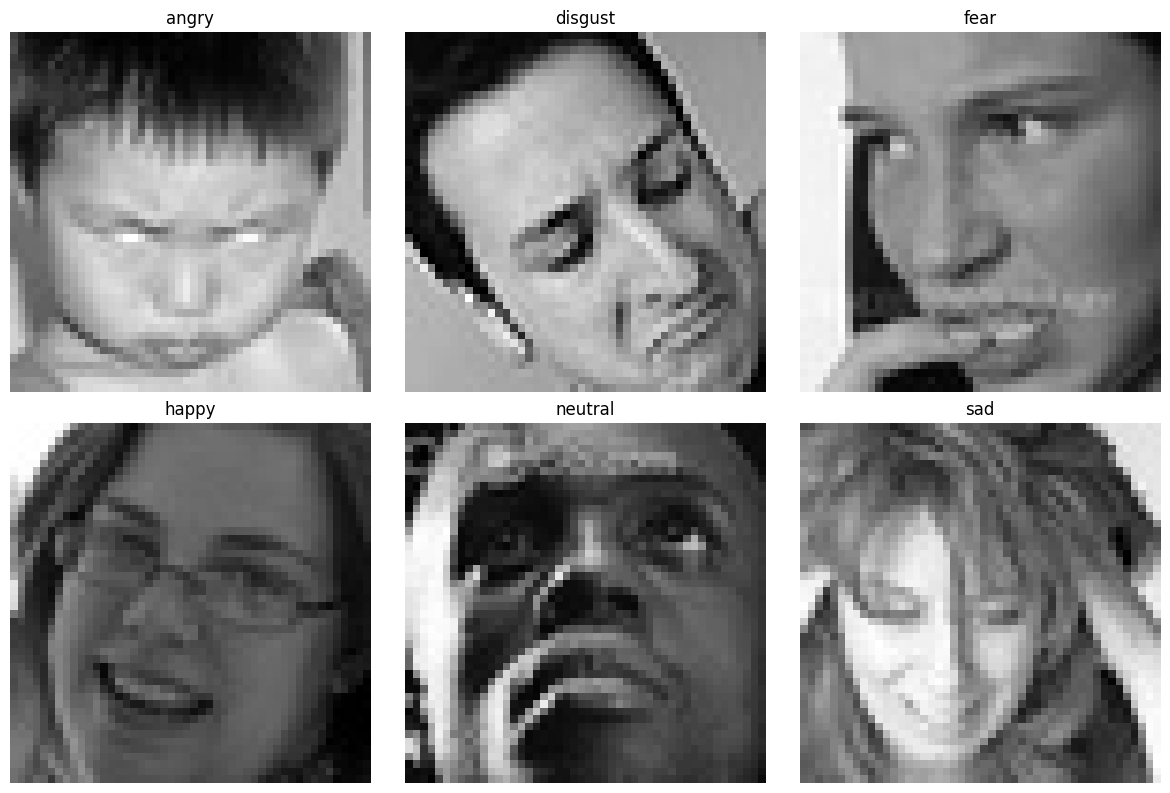

In [5]:
import matplotlib.image as mpimg

plt.figure(figsize=(12, 8))
for i, emotion in enumerate(emotions[:6]):  # show first 6 classes
    img_path = os.path.join(train_dir, emotion, os.listdir(os.path.join(train_dir, emotion))[0])
    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixel values (0–1)
    validation_split=0.2,    # 20% data for validation
    rotation_range=30,       # slight rotations for variety
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",  # convert to grayscale
    batch_size=64,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


In [8]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    color_mode="grayscale",
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)


Found 7178 images belonging to 7 classes.


In [9]:
print("Train Samples:", train_generator.samples)
print("Validation Samples:", val_generator.samples)
print("Test Samples:", test_generator.samples)
print("Emotion Classes:", train_generator.class_indices)

Train Samples: 22968
Validation Samples: 5741
Test Samples: 7178
Emotion Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [11]:
model = Sequential([
    Conv2D(64, (3,3), activation='relu', input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(7, activation='softmax')
])


c:\Users\kinza\AppData\Local\miniconda3\envs\moodai\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [13]:
checkpoint = ModelCheckpoint("best_emotion_model.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[checkpoint, early_stop]
)


c:\Users\kinza\AppData\Local\miniconda3\envs\moodai\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2275 - loss: 2.3099 
Epoch 1: val_accuracy improved from None to 0.25449, saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 5427s 15s/step - accuracy: 0.2431 - loss: 1.9378 - val_accuracy: 0.2545 - val_loss: 1.8075
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.2726 - loss: 1.7722 
Epoch 2: val_accuracy improved from 0.25449 to 0.32555, saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 5570s 16s/step - accuracy: 0.2796 - loss: 1.7608 - val_accuracy: 0.3256 - val_loss: 1.6695
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3136 - loss: 1.7009
Epoch 3: val_accuracy improved from 0.32555 to 0.34942, saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 3394s 9s/step - accuracy: 0.3167 - loss: 1.6930 - val_accuracy: 0.3494 - val_loss: 1.6249
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.3277 - loss: 1.6627 
Epoch 4

In [14]:
import os
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger
from tensorflow.keras.optimizers import Adam

# ====================================
# ⚙️ Step 1: Setup
# ====================================

model_path = 'best_emotion_model.keras'
log_path = 'training_log.csv'

# Agar model pehle se trained hai, usi se resume karo
if os.path.exists(model_path):
    print("🔁 Previous model found! Resuming training...")
    model = load_model(model_path)
else:
    print("🆕 No previous model found, starting fresh training...")
    # 👇 apna model yahan define karo (agar naya start karna hai)
    # Example: model = build_model()  ← tumhara CNN ya transfer learning model

# Re-compile (recommended after loading)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


# ====================================
# 💾 Step 2: Callbacks setup
# ====================================

# 1️⃣ Checkpoint — automatically save best model
checkpoint = ModelCheckpoint(
    filepath=model_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2️⃣ Early stopping — stop if val_loss not improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 3️⃣ CSV Logger — record progress (optional but helpful)
csv_logger = CSVLogger(log_path, append=True)


# ====================================
# 🚀 Step 3: Train / Resume Training
# ====================================

# Tum jitne total epochs chahti ho wo likho
total_epochs = 30

# Agar training dobara start ho rahi hai, purane log se initial_epoch nikal lo
initial_epoch = 0
if os.path.exists(log_path):
    with open(log_path, 'r') as f:
        lines = f.readlines()
        if len(lines) > 1:
            initial_epoch = len(lines) - 1
            print(f"⏩ Resuming from epoch {initial_epoch}")

# Train / Continue Training
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=total_epochs,
    initial_epoch=initial_epoch,
    callbacks=[checkpoint, early_stop, csv_logger],
    verbose=1
)

print("✅ Training Complete! Best model saved as:", model_path)


🔁 Previous model found! Resuming training...
⏩ Resuming from epoch 19


c:\Users\kinza\AppData\Local\miniconda3\envs\moodai\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 20/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4536 - loss: 1.4038
Epoch 20: val_accuracy improved from None to 0.48807, saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 3339s 9s/step - accuracy: 0.4493 - loss: 1.4171 - val_accuracy: 0.4881 - val_loss: 1.3319
Epoch 21/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4565 - loss: 1.4121
Epoch 21: val_accuracy improved from 0.48807 to 0.48842, saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 2196s 6s/step - accuracy: 0.4540 - loss: 1.4184 - val_accuracy: 0.4884 - val_loss: 1.3348
Epoch 22/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4654 - loss: 1.4084
Epoch 22: val_accuracy improved from 0.48842 to 0.50758, saving model to best_emotion_model.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 1909s 5s/step - accuracy: 0.4614 - loss: 1.4112 - val_accuracy: 0.5076 - val_loss: 1.3041
Epoch 23/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.4566 - loss: 1.4048
Epoch 23

In [15]:
from tensorflow.keras.models import load_model

# Load best model
model = load_model('best_emotion_model.keras')

# Evaluate on test data
test_loss, test_acc = model.evaluate(test_generator)
print(f"✅ Test Accuracy: {test_acc*100:.2f}%")


113/113 ━━━━━━━━━━━━━━━━━━━━ 656s 6s/step - accuracy: 0.5372 - loss: 1.2096
✅ Test Accuracy: 53.72%


113/113 ━━━━━━━━━━━━━━━━━━━━ 407s 4s/step


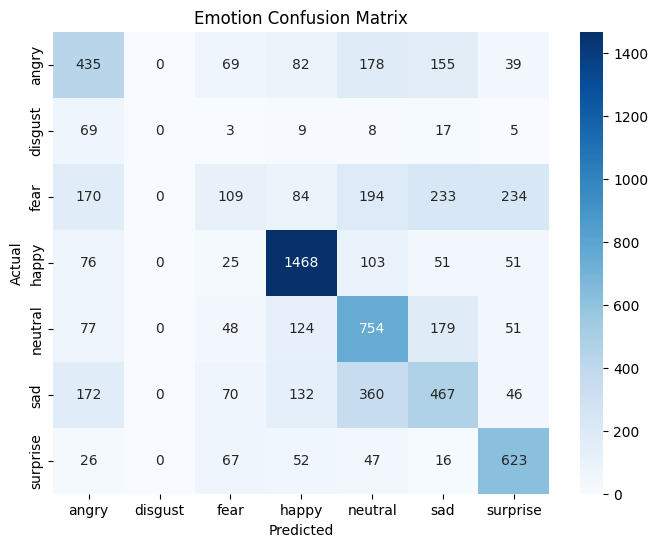

c:\Users\kinza\AppData\Local\miniconda3\envs\moodai\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kinza\AppData\Local\miniconda3\envs\moodai\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\kinza\AppData\Local\miniconda3\envs\moodai\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

              precision    recall  f1-score   support

       angry       0.42      0.45      0.44       958
     disgust       0.00      0.00      0.00       111
        fear       0.28      0.11      0.15      1024
       happy       0.75      0.83      0.79      1774
     neutral       0.46      0.61      0.52      1233
         sad       0.42      0.37      0.39      1247
    surprise       0.59      0.75      0.66       831

    accuracy                           0.54      7178
   macro avg       0.42      0.45      0.42      7178
weighted avg       0.50      0.54      0.51      7178



In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Emotion Confusion Matrix')
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))


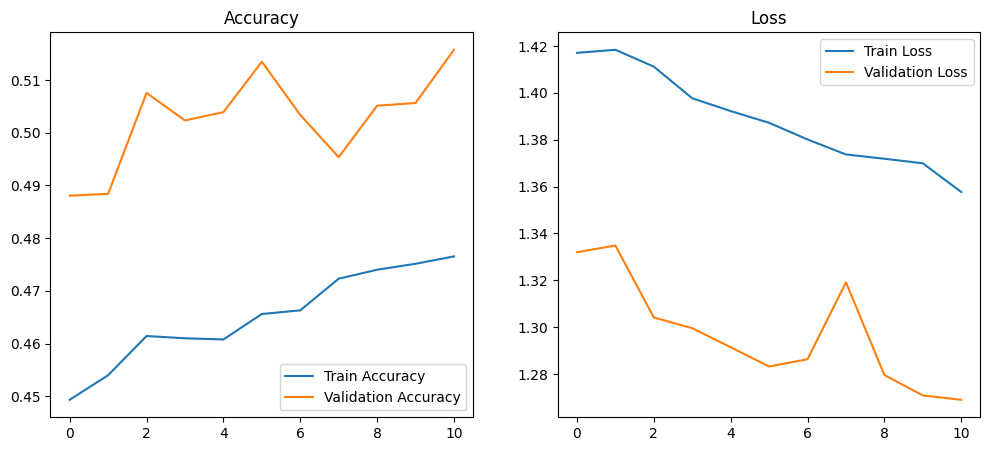

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [ ]:
model.save("final_emotion_detection_model.keras")